In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load image
img = cv2.imread("sig.jpg")

def clean_process(img):
    # Step 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2. Denoise to remove paper grain or texture
    denoised = cv2.fastNlMeansDenoising(gray, None, h=15)

    # Step 3. Create a mask for the ink (dark regions)
    # Invert so that ink is white and background is black
    _, mask = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Step 4. Invert mask back so signature is black (0) and background is white (255)
    inv_mask = cv2.bitwise_not(mask)

    # Step 5. Create a pure white image (same size as input)
    white_bg = np.full_like(img, 255)

    # Step 6. Combine white background with original image using mask
    # Keeps original ink, replaces background with white
    result = np.where(mask[..., None] == 255, img, white_bg)

    return result

# Step 7. Save result
# cv2.imwrite("cleaned_document.png", final)

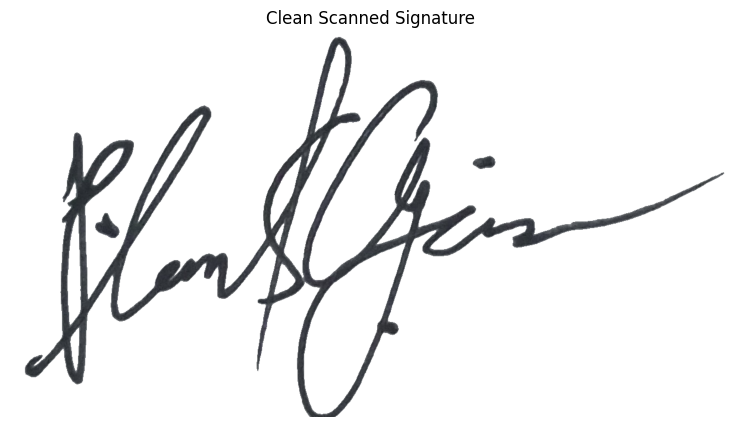

In [21]:
scanned = clean_process(img)

plt.figure(figsize=(10,5))
plt.imshow(scanned, cmap='gray')
plt.title("Clean Scanned Signature")
plt.axis('off')
plt.show()